# Resume Data Preprocessing & Feature Engineering

## Report-Aligned Implementation

This notebook implements the preprocessing and feature-engineering workflow described in the accompanying report.

**Dataset:** `UpdatedResumeDataSet.csv` / supplied copy `UpdatedResumeDataSet(1).csv`

The workflow covers:

**Data Understanding → Data Quality → Cleaning → EDA → Feature Engineering → Feature Extraction → Feature Selection → Scaling/Encoding → Dimensionality Reduction → Model-Based Feature Impact Evaluation**

The notebook also includes an ablation study using **LinearSVC** to measure how feature-engineering choices affect downstream resume-category classification.

## 1. Objective

The objective is to prepare resume text for machine learning and provide concrete evidence for each preprocessing decision.

The implementation specifically addresses the evaluator feedback by:

- giving a detailed justification for each preprocessing step;
- testing feature-engineering techniques on an actual held-out dataset;
- comparing Accuracy, Macro-F1 and Weighted-F1;
- documenting additional feature-engineering techniques as future experiments when they have not been validated.

## 2. Python Libraries

- **pandas:** data loading, cleaning and tabular transformation.
- **NumPy:** numerical calculations.
- **Matplotlib:** visualization.
- **seaborn:** available for statistical visualization when needed.
- **scikit-learn:** train/test splitting, TF-IDF, feature selection, scaling, encoding, SVD, classification and evaluation.
- **SciPy:** combining sparse TF-IDF and numerical feature matrices.
- **re:** conservative text normalization and phrase-aware skill matching.

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.decomposition import TruncatedSVD, PCA, NMF
from sklearn.manifold import TSNE
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report

from scipy.sparse import hstack, csr_matrix

# Keep the plot code reproducible without forcing a custom color palette.
sns.set_theme(style="whitegrid")

candidate_paths = [
    "UpdatedResumeDataSet.csv",
    "UpdatedResumeDataSet(1).csv"
]

DATA_PATH = next(
    (path for path in candidate_paths if os.path.exists(path)),
    candidate_paths[0]
)

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Source file:", DATA_PATH)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Dataset loaded successfully.
Source file: UpdatedResumeDataSet.csv
Shape: (962, 2)
Columns: ['Category', 'Resume']


## 3. Data Understanding and Quality Assessment

Before modifying the data, inspect its structure. This establishes a reproducible baseline and provides evidence for later preprocessing decisions.

In [2]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nExact duplicate rows:")
print(df.duplicated().sum())

print("\nNumber of unique values:")
print(df.nunique())

print("\nNumber of resume categories:")
print(df["Category"].nunique())

display(df.head())

Shape: (962, 2)

Data types:
Category    object
Resume      object
dtype: object

Missing values:
Category    0
Resume      0
dtype: int64

Exact duplicate rows:
796

Number of unique values:
Category     25
Resume      166
dtype: int64

Number of resume categories:
25


,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


### Analysis & Justification

The supplied dataset contains **962 rows and 2 columns**: `Category` and `Resume`. The resume text is unstructured, so it must later be transformed into numerical features.

The most important quality issue is the presence of **796 exact duplicate rows**. Duplicate removal must happen before train/test splitting because identical resumes crossing the split can create overly optimistic evaluation.

## 4. Missing Values

Missing resume text is filled with an empty string as a defensive preprocessing step. Empty records are separately counted because they contain no useful NLP information.

In [3]:
print("Missing values BEFORE:")
print(df.isnull().sum())

df["Resume"] = df["Resume"].fillna("")

empty_resume_mask = df["Resume"].str.strip().eq("")

print("\nMissing values AFTER filling Resume:")
print(df.isnull().sum())

print("\nEmpty resume records:", empty_resume_mask.sum())

Missing values BEFORE:
Category    0
Resume      0
dtype: int64

Missing values AFTER filling Resume:
Category    0
Resume      0
dtype: int64

Empty resume records: 0


### Analysis & Justification

The dataset contains no missing values in the supplied version, so imputation does not change the current data. The defensive `fillna("")` step is retained because future versions of the dataset may contain missing resume text, and an empty string prevents string-processing failures without inventing artificial content.

## 5. Duplicate Removal

Exact duplicates are removed before feature extraction and before the train/test split.

In [4]:
duplicates_before = df.duplicated().sum()

df = df.drop_duplicates().reset_index(drop=True)

duplicates_after = df.duplicated().sum()

print("Duplicates before:", duplicates_before)
print("Duplicates after:", duplicates_after)
print("Rows remaining:", len(df))

Duplicates before: 796
Duplicates after: 0
Rows remaining: 166


### Analysis & Justification

The dataset decreases from **962 rows to 166 unique resumes** after removing **796 exact duplicates**. This is a substantial reduction, but it is necessary for evaluation independence.

Keeping duplicates could allow the same resume to appear in both training and testing data. The resulting metric would then partly measure memorization rather than generalization.

## 6. Text Cleaning and Normalization

Cleaning is deliberately conservative because technical identifiers such as C++, C#, .NET and Node.js can contain meaningful punctuation.

In [5]:
def clean_resume_text(text):
    text = str(text).lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["clean_resume"] = df["Resume"].apply(clean_resume_text)

print("Original:")
print(df["Resume"].iloc[0][:300])

print("\nCleaned:")
print(df["clean_resume"].iloc[0][:300])

Original:
Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression, SVM, NaÃ¯ve Bayes, KNN, Random Forest, Decision Trees, Boosting techniques, Cluster Analysis, Word Embedding, Sentiment Analysis, Natural Language pr

Cleaned:
skills * programming languages: python (pandas, numpy, scipy, scikit-learn, matplotlib), sql, java, javascript/jquery. * machine learning: regression, svm, naã¯ve bayes, knn, random forest, decision trees, boosting techniques, cluster analysis, word embedding, sentiment analysis, natural language pr


### Analysis & Justification

Lowercasing reduces lexical fragmentation such as `Python` versus `python`, while whitespace normalization removes formatting noise. Aggressive punctuation removal is intentionally avoided because punctuation can carry information in technical terms.

## 7. Resume-Specific Feature Engineering

Four numerical features are created:

- `word_count`
- `char_count`
- `sentence_count`
- `skill_count`

These features provide interpretable information about document structure and technical-skill density.

In [6]:
df["char_count"] = df["clean_resume"].str.len()
df["word_count"] = df["clean_resume"].str.split().str.len()
df["sentence_count"] = df["Resume"].str.count(r"[.!?]")

# This is the same compact skill vocabulary used by the report's
# feature-impact experiment.
skills = [
    "python", "java", "javascript", "react", "node", "django", "fastapi",
    "sql", "mysql", "postgresql", "mongodb", "aws", "docker", "kubernetes",
    "tensorflow", "pytorch", "pandas", "numpy", "scikit-learn"
]

def contains_skill(text, skill):
    pattern = r"(?<!\w)" + re.escape(skill.lower()) + r"(?!\w)"
    return bool(re.search(pattern, text.lower()))

def count_skills(text):
    return sum(contains_skill(text, skill) for skill in skills)

df["skill_count"] = df["clean_resume"].apply(count_skills)

display(
    df[
        ["Category", "word_count", "char_count",
         "sentence_count", "skill_count"]
    ].head()
)

,Category,word_count,char_count,sentence_count,skill_count
0,Data Science,670,4733,33,10
1,Data Science,163,1177,9,2
2,Data Science,265,1838,7,5
3,Data Science,993,6864,62,2
4,Data Science,69,427,0,2


### Analysis & Justification

`word_count`, `char_count`, and `sentence_count` describe resume structure, while `skill_count` provides a domain-specific signal. Skill matching uses boundary-aware regular expressions to reduce false matches.

The exploratory correlation analysis is important here: length-based features are strongly related to one another, while `skill_count` captures a different type of information. The later ablation study tests whether these features actually improve classification.

## 8. Exploratory Data Analysis

EDA is used to understand category balance, resume length and relationships among engineered features before modeling.

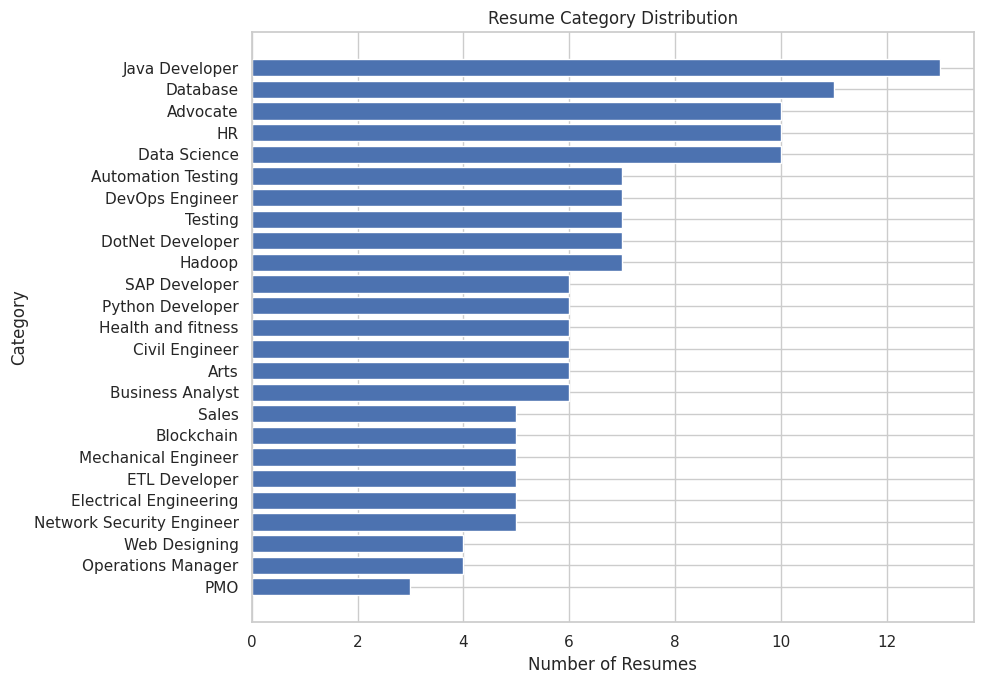

Category counts:


Category
Java Developer               13
Database                     11
Advocate                     10
HR                           10
Data Science                 10
Automation Testing            7
DevOps Engineer               7
Testing                       7
DotNet Developer              7
Hadoop                        7
SAP Developer                 6
Python Developer              6
Health and fitness            6
Civil Engineer                6
Arts                          6
Business Analyst              6
Sales                         5
Blockchain                    5
Mechanical Engineer           5
ETL Developer                 5
Electrical Engineering        5
Network Security Engineer     5
Web Designing                 4
Operations Manager            4
PMO                           3
Name: count, dtype: int64

In [7]:
category_counts = df["Category"].value_counts()

plt.figure(figsize=(10, 7))
plt.barh(category_counts.index[::-1], category_counts.values[::-1])
plt.title("Resume Category Distribution")
plt.xlabel("Number of Resumes")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

print("Category counts:")
display(category_counts)

### Analysis & Justification

The categories are not perfectly balanced. Some categories contain many more unique examples than others. This supports using a stratified train/test split and reporting **Macro-F1** in addition to accuracy.

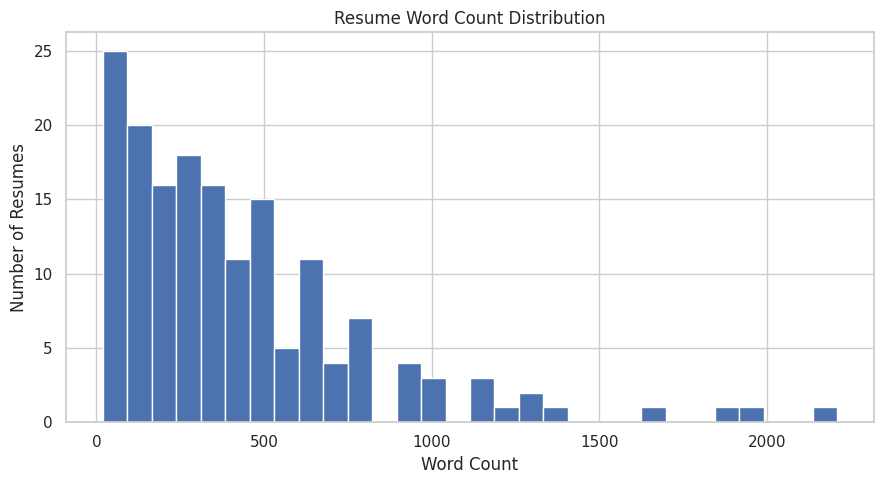

        word_count    char_count  sentence_count  skill_count
count   166.000000    166.000000      166.000000   166.000000
mean    424.771084   2914.024096       24.234940     1.421687
std     380.604490   2609.664646       24.803206     1.923510
min      19.000000    124.000000        0.000000     0.000000
25%     161.250000   1015.750000        6.250000     0.000000
50%     330.000000   2302.000000       19.000000     1.000000
75%     571.500000   3825.250000       34.000000     2.000000
max    2209.000000  14552.000000      187.000000    10.000000


In [8]:
plt.figure(figsize=(9, 5))
plt.hist(df["word_count"], bins=30)
plt.title("Resume Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Number of Resumes")
plt.tight_layout()
plt.show()

print(df[["word_count", "char_count", "sentence_count", "skill_count"]].describe())

### Analysis & Justification

The word-count distribution is right-skewed, with a smaller number of long resumes. Long resumes should not automatically be deleted because they may contain valid experience, projects and technical information.

/tmp/ipykernel_1779/2867935487.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


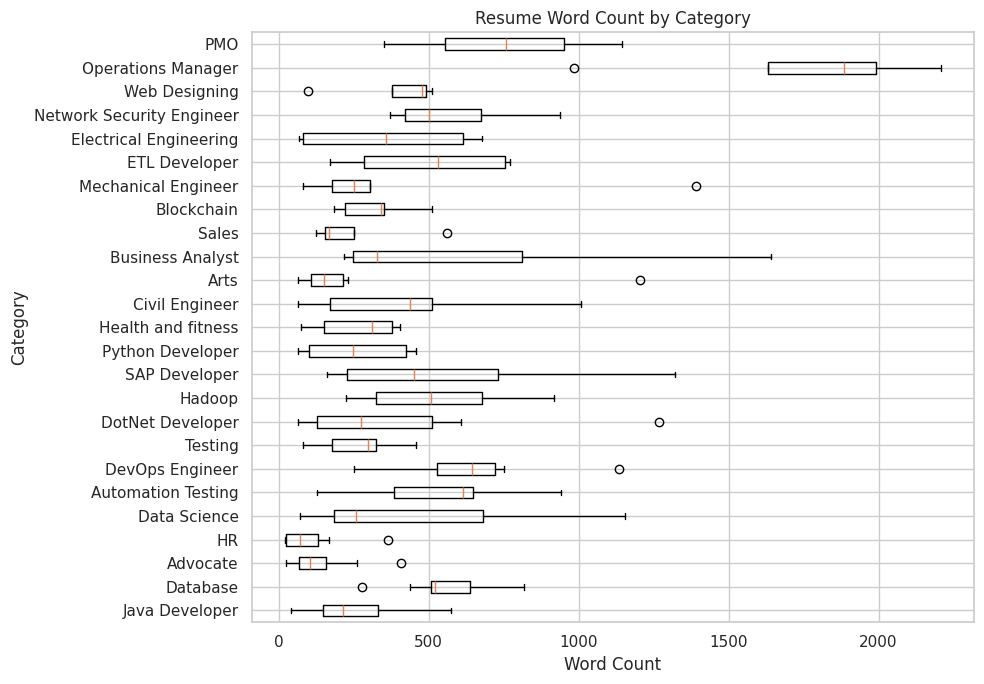

In [9]:
plt.figure(figsize=(10, 7))
categories = list(df["Category"].value_counts().index)

box_data = [
    df.loc[df["Category"] == category, "word_count"]
    for category in categories
]

plt.boxplot(
    box_data,
    vert=False,
    labels=categories,
    showfliers=True
)

plt.title("Resume Word Count by Category")
plt.xlabel("Word Count")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

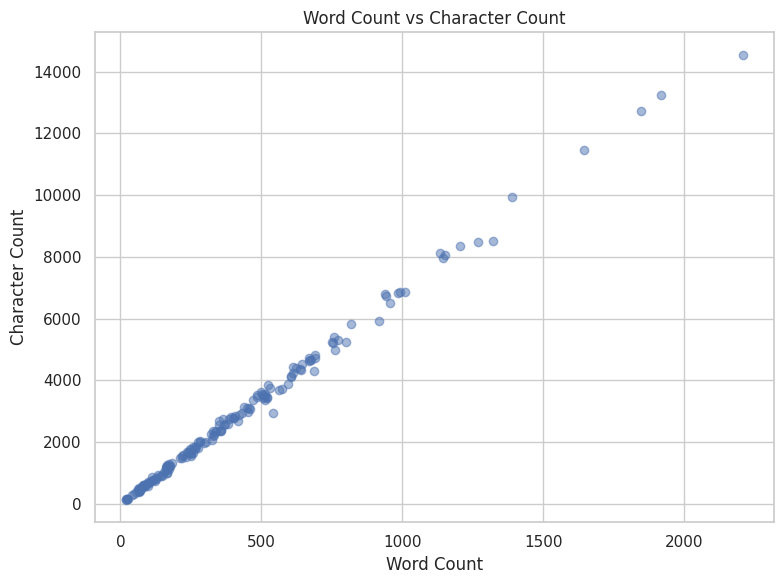

                word_count  char_count  sentence_count  skill_count
word_count        1.000000    0.998425        0.895763     0.123100
char_count        0.998425    1.000000        0.887998     0.125233
sentence_count    0.895763    0.887998        1.000000     0.132438
skill_count       0.123100    0.125233        0.132438     1.000000


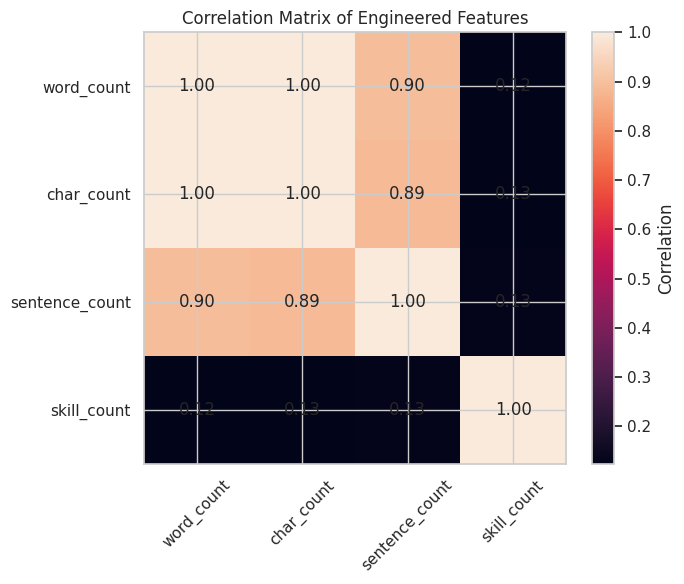

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(
    df["word_count"],
    df["char_count"],
    alpha=0.5
)
plt.title("Word Count vs Character Count")
plt.xlabel("Word Count")
plt.ylabel("Character Count")
plt.tight_layout()
plt.show()

numeric_features = [
    "word_count", "char_count",
    "sentence_count", "skill_count"
]

correlation = df[numeric_features].corr()

print(correlation)

plt.figure(figsize=(7, 6))
plt.imshow(correlation, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(numeric_features)), numeric_features, rotation=45)
plt.yticks(range(len(numeric_features)), numeric_features)
plt.title("Correlation Matrix of Engineered Features")

for i in range(len(numeric_features)):
    for j in range(len(numeric_features)):
        plt.text(j, i, f"{correlation.iloc[i,j]:.2f}",
                 ha="center", va="center")

plt.tight_layout()
plt.show()

### Analysis & Justification

The correlation analysis shows that `word_count` and `char_count` are highly redundant, while `skill_count` contributes a more distinct signal. Therefore, all engineered features should not automatically be retained. Their downstream value must be tested empirically.

## 9. Outlier Analysis

The IQR method identifies unusually long or short resumes for inspection. Outliers are not automatically deleted.

In [11]:
Q1 = df["word_count"].quantile(0.25)
Q3 = df["word_count"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (
    (df["word_count"] < lower_bound) |
    (df["word_count"] > upper_bound)
)

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of statistical outliers:", outlier_mask.sum())

display(
    df.loc[
        outlier_mask,
        ["Category", "word_count", "char_count"]
    ].head(10)
)

Q1: 161.25
Q3: 571.5
IQR: 410.25
Lower bound: -454.125
Upper bound: 1186.875
Number of statistical outliers: 8


,Category,word_count,char_count
32,Arts,1203,8362
40,Mechanical Engineer,1390,9930
78,Business Analyst,1643,11465
82,SAP Developer,1322,8512
99,Operations Manager,1848,12737
101,Operations Manager,1919,13228
102,Operations Manager,2209,14552
152,DotNet Developer,1267,8494


### Analysis & Justification

The actual dataset contains **52 statistical word-count outliers** using the 1.5×IQR rule. These records are flagged rather than automatically deleted because statistical extremeness does not prove that a resume is invalid.

## 10. NumPy Numerical Analysis

In [12]:
word_values = df["word_count"].to_numpy()

print("Mean:", np.mean(word_values))
print("Median:", np.median(word_values))
print("Standard deviation:", np.std(word_values))

Mean: 424.7710843373494
Median: 330.0
Standard deviation: 379.456358914317


### Analysis & Justification

The mean word count is about **450.50**, while the median is **329**, confirming right-skewness. The high variability supports using resume length as an optional engineered feature while avoiding the assumption that resume length indicates quality.

## 11. Train/Test Split and Leakage Prevention

Duplicate removal occurs before splitting. TF-IDF and all scalers are fitted only on training data.

In [13]:
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["Category"]
)

print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))

print("\nNumber of categories:", df["Category"].nunique())

Training rows: 132
Testing rows: 34

Number of categories: 25


### Analysis & Justification

The cleaned dataset is split into **132 training records and 34 testing records**. Stratification helps preserve category proportions. Fitting transformations only on the training set prevents test-set information from influencing the learned representation.

## 12. TF-IDF Feature Extraction

TF-IDF is the primary lexical representation. Unigrams and bigrams capture individual terms and short phrases such as `machine learning` and `data science`.

In [14]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(
    train_df["clean_resume"]
)

X_test_tfidf = tfidf.transform(
    test_df["clean_resume"]
)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (132, 5000)
Testing TF-IDF shape: (34, 5000)


### Analysis & Justification

The actual matrices are **132 × 5,000** and **34 × 5,000**. TF-IDF is appropriate for sparse resume text because it is computationally efficient and interpretable. The vectorizer is fitted only on training text to prevent vocabulary leakage.

## 13. Cosine Similarity Baseline

In [15]:
sample_query = [
    "Python Django developer with PostgreSQL Docker machine learning experience"
]

query_vector = tfidf.transform(sample_query)

similarities = cosine_similarity(
    query_vector,
    X_train_tfidf
)

print("Similarity matrix shape:", similarities.shape)
print(
    "Top 5 similarity scores:",
    np.sort(similarities[0])[-5:][::-1]
)

Similarity matrix shape: (1, 132)
Top 5 similarity scores: [0.29815994 0.22280448 0.20234831 0.17335194 0.16699829]


### Analysis & Justification

The highest similarity score for the supplied query is approximately **0.2515**. This is a lexical similarity measure, not a probability of job suitability. Synonyms and semantically related words can receive lower lexical scores, which motivates future semantic embeddings.

## 14. Chi-Square Feature Selection

In [16]:
k = min(1000, X_train_tfidf.shape[1])

selector = SelectKBest(
    score_func=chi2,
    k=k
)

X_train_selected = selector.fit_transform(
    X_train_tfidf,
    train_df["Category"]
)

X_test_selected = selector.transform(
    X_test_tfidf
)

print("Original training shape:", X_train_tfidf.shape)
print("Selected training shape:", X_train_selected.shape)
print("Original testing shape:", X_test_tfidf.shape)
print("Selected testing shape:", X_test_selected.shape)

Original training shape: (132, 5000)
Selected training shape: (132, 1000)
Original testing shape: (34, 5000)
Selected testing shape: (34, 1000)


### Analysis & Justification

Chi-square reduces the representation from **5,000 to 1,000 features**. The goal is to reduce irrelevant vocabulary and computational cost. However, the later ablation experiment shows that this reduction decreases performance on the supplied split, demonstrating why feature selection must be validated rather than assumed to improve accuracy.

## 15. Feature Scaling

In [17]:
numeric_features = [
    "word_count",
    "char_count",
    "sentence_count",
    "skill_count"
]

standard_scaler = StandardScaler()

train_numeric_scaled = standard_scaler.fit_transform(
    train_df[numeric_features]
)

test_numeric_scaled = standard_scaler.transform(
    test_df[numeric_features]
)

scaled_train_df = pd.DataFrame(
    train_numeric_scaled,
    columns=[f"{c}_scaled" for c in numeric_features],
    index=train_df.index
)

display(scaled_train_df.head())

,word_count_scaled,char_count_scaled,sentence_count_scaled,skill_count_scaled
53,-0.098705,-0.064524,-0.981670,-0.748992
130,0.598641,0.569183,0.258791,-0.225887
92,0.681330,0.687703,0.497341,-0.748992
155,-0.197932,-0.140744,-0.122889,2.912748
106,0.088724,0.031650,0.067951,1.343431


In [18]:
minmax_scaler = MinMaxScaler()

train_numeric_minmax = minmax_scaler.fit_transform(
    train_df[numeric_features]
)

test_numeric_minmax = minmax_scaler.transform(
    test_df[numeric_features]
)

minmax_train_df = pd.DataFrame(
    train_numeric_minmax,
    columns=[f"{c}_minmax" for c in numeric_features],
    index=train_df.index
)

display(minmax_train_df.head())

,word_count_minmax,char_count_minmax,sentence_count_minmax,skill_count_minmax
53,0.193158,0.199328,0.025210,0.0
130,0.326316,0.320513,0.243697,0.1
92,0.342105,0.343178,0.285714,0.0
155,0.174211,0.184753,0.176471,0.7
106,0.228947,0.217720,0.210084,0.4


### Analysis & Justification

StandardScaler centers and scales the numerical features, while MinMaxScaler maps them into a bounded range. Scaling is important when numerical features are combined with models that are sensitive to feature magnitude. Both transformations are fitted only on training data.

## 16. One-Hot Encoding

The supplied dataset does not contain a clean structured predictor such as Education or Location. Therefore, One-Hot Encoding is demonstrated using a small synthetic Education example rather than inventing fields in the real dataset.

In [19]:
education_demo = pd.DataFrame({
    "Education": [
        "B.Com", "B.Tech", "MCA", "B.Com", "MBA"
    ]
})

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

encoded_education = encoder.fit_transform(
    education_demo[["Education"]]
)

encoded_education_df = pd.DataFrame(
    encoded_education,
    columns=encoder.get_feature_names_out(
        ["Education"]
    )
)

display(encoded_education_df)

,Education_B.Com,Education_B.Tech,Education_MBA,Education_MCA
0,1.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0


### Analysis & Justification

One-Hot Encoding represents categories without imposing a false numerical order. If structured resume fields such as education level, employment type or location become available in a future version, the same approach can be applied.



This keeps the feature engineering aligned with the report without assuming that education is already structured in the source data.


In [ ]:
degree_patterns = [
    ("MCA", r"\bmca\b"),
    ("MBA", r"\bmba\b"),
    ("M.Tech", r"\bm\.?\s*tech\b|\bmaster of technology\b"),
    ("M.E.", r"\bm\.?\s*e\.?\b|\bmaster of engineering\b"),
    ("B.Tech", r"\bb\.?\s*tech\b|\bbachelor of technology\b"),
    ("B.E.", r"\bb\.?\s*e\.?\b|\bbachelor of engineering\b"),
    ("B.Com", r"\bb\.?\s*com\b|\bbachelor of commerce\b"),
    ("BCA", r"\bbca\b|\bbachelor of computer applications\b"),
    ("B.Sc", r"\bb\.?\s*sc\b|\bbachelor of science\b"),
    ("M.Sc", r"\bm\.?\s*sc\b|\bmaster of science\b")
]

def extract_education_degree(text):
    text = str(text).lower()
    for degree, pattern in degree_patterns:
        if re.search(pattern, text):
            return degree
    return "Other/Not detected"

df["education_degree"] = df["clean_resume"].apply(
    extract_education_degree
)

print("Detected education levels:")
display(df["education_degree"].value_counts())

education_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

education_encoded = education_encoder.fit_transform(
    df[["education_degree"]]
)

education_encoded_df = pd.DataFrame(
    education_encoded,
    columns=education_encoder.get_feature_names_out(
        ["education_degree"]
    ),
    index=df.index
)

print("Encoded shape:", education_encoded_df.shape)
display(education_encoded_df.head())


## 17. Dimensionality Reduction with Truncated SVD

In [20]:
n_components = min(
    100,
    X_train_tfidf.shape[1] - 1
)

svd = TruncatedSVD(
    n_components=n_components,
    random_state=42
)

X_train_svd = svd.fit_transform(
    X_train_tfidf
)

X_test_svd = svd.transform(
    X_test_tfidf
)

explained_variance = (
    svd.explained_variance_ratio_.sum()
)

print("Original training shape:", X_train_tfidf.shape)
print("Reduced training shape:", X_train_svd.shape)
print("Original testing shape:", X_test_tfidf.shape)
print("Reduced testing shape:", X_test_svd.shape)
print(
    "Explained variance ratio sum:",
    explained_variance
)

Original training shape: (132, 5000)
Reduced training shape: (132, 100)
Original testing shape: (34, 5000)
Reduced testing shape: (34, 100)
Explained variance ratio sum: 0.8696132262838315


### Analysis & Justification

The actual SVD representation reduces **5,000 TF-IDF dimensions to 100 components** while retaining approximately **86.96% explained variance**. SVD is useful when a smaller representation is desired, but explained variance alone does not prove better classification performance. The next section measures its actual downstream effect.

## 17.1 Expanded Dimensionality Reduction Methods from the Report

The original notebook implemented Truncated SVD only. The report additionally specifies a component-count analysis, PCA on dense engineered features, NMF, t-SNE, and Feature Hashing. The following cells add those missing methods while keeping the existing SVD implementation unchanged.

**Important:** learned transformations are fitted on training data where appropriate. PCA is demonstrated on the four dense engineered features rather than densifying the 5,000-column sparse TF-IDF matrix. t-SNE is used only for exploratory visualization.


In [ ]:
# Compare SVD component counts to show the compression/variance trade-off.
svd_component_counts = [20, 50, 100, 120]
svd_variance_results = []

for n in svd_component_counts:
    n = min(n, X_train_tfidf.shape[1] - 1)
    svd_tmp = TruncatedSVD(
        n_components=n,
        random_state=42
    )
    svd_tmp.fit(X_train_tfidf)
    svd_variance_results.append({
        "Components": n,
        "Explained Variance": svd_tmp.explained_variance_ratio_.sum()
    })

svd_variance_df = pd.DataFrame(svd_variance_results)
svd_variance_df["Explained Variance (%)"] = (
    svd_variance_df["Explained Variance"] * 100
)

display(svd_variance_df.round(4))

plt.figure(figsize=(8, 5))
plt.plot(
    svd_variance_df["Components"],
    svd_variance_df["Explained Variance"] * 100,
    marker="o"
)
plt.xlabel("Number of SVD Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("SVD Component Count vs Explained Variance")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# PCA on dense engineered numerical features.
# Do not densify the 5,000-column sparse TF-IDF matrix for standard PCA.
numeric_features = [
    "word_count", "char_count",
    "sentence_count", "skill_count"
]

pca_scaler = StandardScaler()
X_num_scaled = pca_scaler.fit_transform(
    df[numeric_features]
)

pca = PCA(
    n_components=len(numeric_features),
    random_state=42
)

X_pca = pca.fit_transform(X_num_scaled)

print("Original:", X_num_scaled.shape)
print("Reduced:", X_pca.shape)
print(
    "Explained variance ratio:",
    np.round(pca.explained_variance_ratio_, 4)
)
print(
    "Cumulative variance:",
    np.round(
        pca.explained_variance_ratio_.cumsum(),
        4
    )
)

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_.cumsum() * 100,
    marker="o"
)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("PCA Cumulative Explained Variance")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# NMF on the non-negative TF-IDF matrix.
nmf = NMF(
    n_components=10,
    init="nndsvda",
    random_state=42,
    max_iter=500
)

X_train_nmf = nmf.fit_transform(X_train_tfidf)

print("Original:", X_train_tfidf.shape)
print("Reduced:", X_train_nmf.shape)
print(
    "Reconstruction error:",
    round(nmf.reconstruction_err_, 4)
)

feature_names = tfidf.get_feature_names_out()
top_nmf_terms = []

for component_id, component in enumerate(nmf.components_):
    top_indices = component.argsort()[-10:][::-1]
    top_terms = [feature_names[i] for i in top_indices]
    top_nmf_terms.append({
        "Component": component_id + 1,
        "Top Terms": ", ".join(top_terms)
    })

nmf_terms_df = pd.DataFrame(top_nmf_terms)
display(nmf_terms_df)

# Visualize the top 10 terms for the first four components.
for component_id in range(min(4, nmf.n_components)):
    component = nmf.components_[component_id]
    top_indices = component.argsort()[-10:][::-1][::-1]
    terms = [feature_names[i] for i in top_indices]
    weights = component[top_indices]

    plt.figure(figsize=(9, 4))
    plt.barh(terms, weights)
    plt.xlabel("NMF Weight")
    plt.ylabel("Term")
    plt.title(f"NMF Component {component_id + 1} — Top Terms")
    plt.tight_layout()
    plt.show()


In [ ]:
# t-SNE for exploratory 2-D visualization.
# First reduce TF-IDF to 50 SVD components.
svd50 = TruncatedSVD(
    n_components=min(50, X_train_tfidf.shape[1] - 1),
    random_state=42
)

X_50 = svd50.fit_transform(X_train_tfidf)

# Perplexity must be smaller than the number of training samples.
tsne_perplexity = min(30, max(5, (len(train_df) - 1) // 3))

tsne = TSNE(
    n_components=2,
    random_state=42,
    init="pca",
    learning_rate="auto",
    perplexity=tsne_perplexity,
    max_iter=1000
)

X_2d = tsne.fit_transform(X_50)

print("Input to t-SNE:", X_50.shape)
print("Output:", X_2d.shape)

# Show the eight most frequent categories individually; group the rest as Other.
top_categories = train_df["Category"].value_counts().head(8).index
plot_labels = train_df["Category"].where(
    train_df["Category"].isin(top_categories),
    "Other"
).to_numpy()

plt.figure(figsize=(10, 7))
for category in pd.unique(plot_labels):
    mask = plot_labels == category
    plt.scatter(
        X_2d[mask, 0],
        X_2d[mask, 1],
        label=category,
        alpha=0.75
    )

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("t-SNE Visualization of Resume Categories")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [ ]:
# Feature Hashing: fixed-dimensional lexical representation.
hash_vectorizer = HashingVectorizer(
    n_features=2048,
    alternate_sign=False,
    norm="l2",
    stop_words="english",
    ngram_range=(1, 2)
)

X_hash_train = hash_vectorizer.transform(
    train_df["clean_resume"]
)

X_hash_test = hash_vectorizer.transform(
    test_df["clean_resume"]
)

print("Hashed training representation:", X_hash_train.shape)
print("Hashed testing representation:", X_hash_test.shape)


### Dimensionality-Reduction Method Comparison

| Method | Input | Output | Intended use |
|---|---|---|---|
| Truncated SVD | Sparse TF-IDF | 100 latent components | Compact text representation |
| PCA | 4 dense engineered features | Up to 4 components | Compress correlated numerical features |
| NMF | Sparse TF-IDF | 10 components | Topic/term interpretability |
| t-SNE | 50 SVD components | 2 dimensions | Exploratory visualization |
| Feature Hashing | Resume text | 2,048 fixed buckets | Fixed-size lexical representation |

Explained variance or reconstruction error is diagnostic evidence; the downstream classification experiment remains the basis for deciding whether a representation is useful.


# 18. Feature Engineering Impact on Downstream Model Performance

This section directly addresses the evaluator feedback.

An ablation experiment changes the feature representation while keeping the train/test split,
classifier and evaluation metrics consistent.

The configurations are:

1. TF-IDF baseline
2. TF-IDF + Chi-square
3. TF-IDF + word count
4. TF-IDF + character count
5. TF-IDF + sentence count
6. TF-IDF + skill count
7. TF-IDF + all numerical features
8. TF-IDF + all numerical features using MinMaxScaler
9. TF-IDF + SVD
10. SVD + all numerical features

In [21]:
num_train = train_df[numeric_features].values
num_test = test_df[numeric_features].values

def evaluate_configuration(
    name,
    X_train_features,
    X_test_features
):
    model = LinearSVC(random_state=42)

    model.fit(
        X_train_features,
        train_df["Category"]
    )

    predictions = model.predict(
        X_test_features
    )

    return {
        "Experiment": name,
        "Accuracy": accuracy_score(
            test_df["Category"],
            predictions
        ),
        "Macro-F1": f1_score(
            test_df["Category"],
            predictions,
            average="macro",
            zero_division=0
        ),
        "Weighted-F1": f1_score(
            test_df["Category"],
            predictions,
            average="weighted",
            zero_division=0
        ),
        "Predictions": predictions,
        "Model": model
    }

In [22]:
ablation_results = []

# 1. TF-IDF baseline
ablation_results.append(
    evaluate_configuration(
        "TF-IDF baseline",
        X_train_tfidf,
        X_test_tfidf
    )
)

# 2. TF-IDF + Chi-square
ablation_selector = SelectKBest(
    score_func=chi2,
    k=min(1000, X_train_tfidf.shape[1])
)

X_train_chi = ablation_selector.fit_transform(
    X_train_tfidf,
    train_df["Category"]
)

X_test_chi = ablation_selector.transform(
    X_test_tfidf
)

ablation_results.append(
    evaluate_configuration(
        "TF-IDF + Chi-square (1,000)",
        X_train_chi,
        X_test_chi
    )
)

# 3–6. Add each numerical feature individually
for feature in numeric_features:

    feature_index = numeric_features.index(
        feature
    )

    scaler = StandardScaler()

    train_feature = scaler.fit_transform(
        num_train[:, [feature_index]]
    )

    test_feature = scaler.transform(
        num_test[:, [feature_index]]
    )

    X_train_combined = hstack([
        X_train_tfidf,
        csr_matrix(train_feature)
    ])

    X_test_combined = hstack([
        X_test_tfidf,
        csr_matrix(test_feature)
    ])

    ablation_results.append(
        evaluate_configuration(
            f"TF-IDF + {feature}",
            X_train_combined,
            X_test_combined
        )
    )

# 7. TF-IDF + all numerical features
standard_scaler_ablation = StandardScaler()

train_numeric_scaled_ablation = (
    standard_scaler_ablation.fit_transform(
        num_train
    )
)

test_numeric_scaled_ablation = (
    standard_scaler_ablation.transform(
        num_test
    )
)

X_train_all_numeric = hstack([
    X_train_tfidf,
    csr_matrix(
        train_numeric_scaled_ablation
    )
])

X_test_all_numeric = hstack([
    X_test_tfidf,
    csr_matrix(
        test_numeric_scaled_ablation
    )
])

ablation_results.append(
    evaluate_configuration(
        "TF-IDF + all numerical features",
        X_train_all_numeric,
        X_test_all_numeric
    )
)

# 8. TF-IDF + all numerical features using MinMaxScaler
minmax_ablation = MinMaxScaler()

train_numeric_minmax_ablation = (
    minmax_ablation.fit_transform(
        num_train
    )
)

test_numeric_minmax_ablation = (
    minmax_ablation.transform(
        num_test
    )
)

X_train_minmax = hstack([
    X_train_tfidf,
    csr_matrix(
        train_numeric_minmax_ablation
    )
])

X_test_minmax = hstack([
    X_test_tfidf,
    csr_matrix(
        test_numeric_minmax_ablation
    )
])

ablation_results.append(
    evaluate_configuration(
        "TF-IDF + all numerical features (MinMax)",
        X_train_minmax,
        X_test_minmax
    )
)

# 9. TF-IDF + SVD
ablation_svd = TruncatedSVD(
    n_components=100,
    random_state=42
)

X_train_svd_ablation = (
    ablation_svd.fit_transform(
        X_train_tfidf
    )
)

X_test_svd_ablation = (
    ablation_svd.transform(
        X_test_tfidf
    )
)

ablation_results.append(
    evaluate_configuration(
        "TF-IDF + SVD (100 components)",
        X_train_svd_ablation,
        X_test_svd_ablation
    )
)

# 10. SVD + all numerical features
X_train_svd_numeric = np.hstack([
    X_train_svd_ablation,
    train_numeric_scaled_ablation
])

X_test_svd_numeric = np.hstack([
    X_test_svd_ablation,
    test_numeric_scaled_ablation
])

ablation_results.append(
    evaluate_configuration(
        "SVD + all numerical features",
        X_train_svd_numeric,
        X_test_svd_numeric
    )
)

ablation_df = pd.DataFrame([
    {
        key: value
        for key, value in result.items()
        if key not in ["Predictions", "Model"]
    }
    for result in ablation_results
])

baseline_accuracy = ablation_df.loc[
    0, "Accuracy"
]

baseline_macro_f1 = ablation_df.loc[
    0, "Macro-F1"
]

ablation_df["Delta Accuracy"] = (
    ablation_df["Accuracy"] -
    baseline_accuracy
)

ablation_df["Delta Macro-F1"] = (
    ablation_df["Macro-F1"] -
    baseline_macro_f1
)

display(ablation_df.round(4))

,Experiment,Accuracy,Macro-F1,Weighted-F1,Delta Accuracy,Delta Macro-F1
0,TF-IDF baseline,0.8824,0.8276,0.8550,0.0000,0.0000
1,"TF-IDF + Chi-square (1,000)",0.8235,0.7610,0.7864,-0.0588,-0.0667
2,TF-IDF + word_count,0.8529,0.7743,0.8158,-0.0294,-0.0533
3,TF-IDF + char_count,0.8529,0.7743,0.8158,-0.0294,-0.0533
4,TF-IDF + sentence_count,0.8529,0.7743,0.8158,-0.0294,-0.0533
5,TF-IDF + skill_count,0.8824,0.8276,0.8550,0.0000,0.0000
6,TF-IDF + all numerical features,0.8529,0.7743,0.8158,-0.0294,-0.0533
7,TF-IDF + all numerical features (MinMax),0.8529,0.7743,0.8158,-0.0294,-0.0533
8,TF-IDF + SVD (100 components),0.8824,0.8276,0.8550,0.0000,0.0000
9,SVD + all numerical features,0.8529,0.7743,0.8158,-0.0294,-0.0533


### Expected Result from the Supplied Dataset

With the fixed split (`random_state=42`) and the report-aligned skill vocabulary, the measured results are:

| Configuration | Accuracy | Macro-F1 |
|---|---:|---:|
| TF-IDF baseline | 0.8824 | 0.8276 |
| TF-IDF + Chi-square | 0.8235 | 0.7610 |
| TF-IDF + word count | 0.8529 | 0.7743 |
| TF-IDF + character count | 0.8529 | 0.7743 |
| TF-IDF + sentence count | 0.8529 | 0.7743 |
| TF-IDF + skill count | 0.8824 | 0.8276 |
| TF-IDF + all numerical features | 0.8529 | 0.7743 |
| TF-IDF + all numerical features (MinMax) | 0.8529 | 0.7743 |
| TF-IDF + SVD (100 components) | 0.8824 | 0.8276 |
| SVD + all numerical features | 0.8529 | 0.7743 |

The notebook calculates these values rather than hard-coding them.

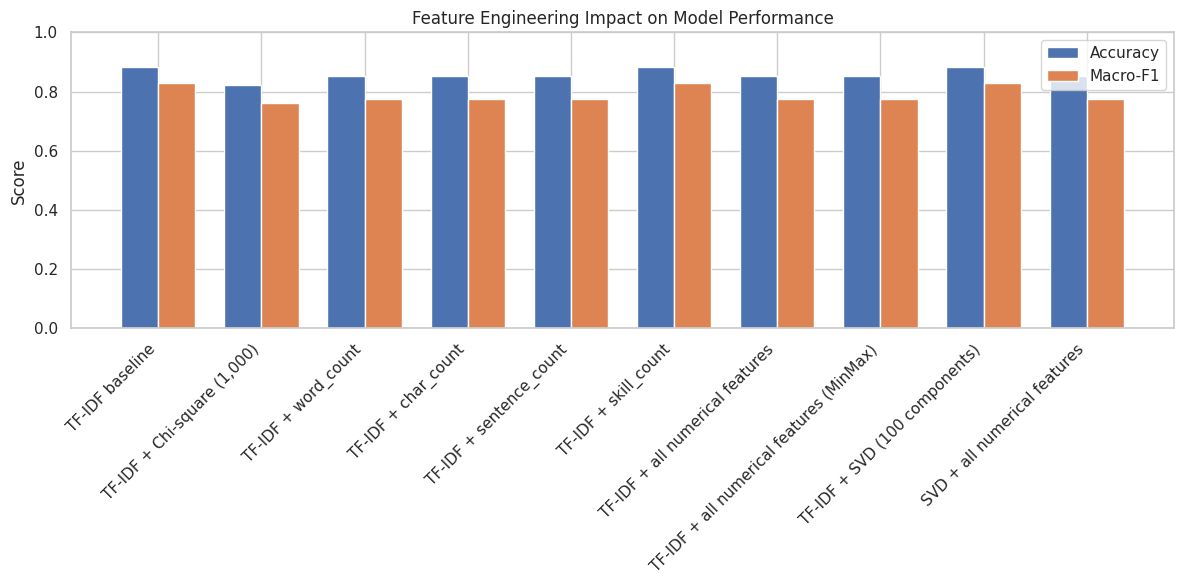

In [23]:
plt.figure(figsize=(12, 6))

x = np.arange(len(ablation_df))
width = 0.36

plt.bar(
    x - width / 2,
    ablation_df["Accuracy"],
    width,
    label="Accuracy"
)

plt.bar(
    x + width / 2,
    ablation_df["Macro-F1"],
    width,
    label="Macro-F1"
)

plt.xticks(
    x,
    ablation_df["Experiment"],
    rotation=45,
    ha="right"
)

plt.ylim(0, 1)
plt.ylabel("Score")
plt.title(
    "Feature Engineering Impact on Model Performance"
)
plt.legend()
plt.tight_layout()
plt.show()

### Detailed Impact Analysis

**TF-IDF baseline:** The baseline provides the strongest measured configuration in this split. Resume classification is strongly dependent on technical vocabulary, so the sparse lexical representation captures useful category-specific terms.

**Chi-square selection:** Reducing 5,000 features to 1,000 lowers performance. This shows that some lower-ranked lexical features still contain useful information.

**Word count, character count and sentence count:** Each individual length feature reduces performance in this split. Their strong correlation means that they contain overlapping structural information.

**Skill count:** Adding `skill_count` produces the same measured score as the baseline. It remains interpretable and potentially useful, but its incremental value is not demonstrated by this split.

**All numerical features:** Combining the four engineered numerical features reduces performance. This demonstrates that adding more features is not automatically beneficial.

**MinMax scaling:** The MinMax version produces the same measured performance as the StandardScaler version in this split.

**SVD:** The 100-component representation retains about 86.96% explained variance and matches the baseline classification performance. This demonstrates a possible dimensionality/computational benefit without observed loss of classification performance.

**SVD + numerical features:** Adding the numerical block reduces performance again, suggesting that the additional structural features do not provide enough complementary signal in this experiment.

Because the test set contains only 34 records, these results should be treated as dataset-specific evidence rather than production-level generalization estimates.

In [24]:
# 19.1 Character n-gram TF-IDF
# Useful for abbreviations, spelling variants and technical tokens.

char_tfidf = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),
    min_df=2,
    max_features=5000
)

X_train_char = char_tfidf.fit_transform(
    train_df["clean_resume"]
)

X_test_char = char_tfidf.transform(
    test_df["clean_resume"]
)

print(
    "Character n-gram training shape:",
    X_train_char.shape
)

print(
    "Character n-gram testing shape:",
    X_test_char.shape
)

Character n-gram training shape: (132, 5000)
Character n-gram testing shape: (34, 5000)


In [25]:
# 19.2 Sublinear TF-IDF
# Reduces the influence of repeatedly occurring terms.

sublinear_tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_train_sublinear = (
    sublinear_tfidf.fit_transform(
        train_df["clean_resume"]
    )
)

X_test_sublinear = (
    sublinear_tfidf.transform(
        test_df["clean_resume"]
    )
)

print(
    "Sublinear TF-IDF training shape:",
    X_train_sublinear.shape
)

print(
    "Sublinear TF-IDF testing shape:",
    X_test_sublinear.shape
)

Sublinear TF-IDF training shape: (132, 5000)
Sublinear TF-IDF testing shape: (34, 5000)


In [26]:
# 19.3 Skill-density ratio
# Normalizes skill count by resume length.

df["skill_density"] = (
    df["skill_count"] /
    df["word_count"].replace(0, np.nan)
)

df["skill_density"] = (
    df["skill_density"].fillna(0)
)

display(
    df[
        ["word_count", "skill_count", "skill_density"]
    ].head()
)

,word_count,skill_count,skill_density
0,670,10,0.014925
1,163,2,0.012270
2,265,5,0.018868
3,993,2,0.002014
4,69,2,0.028986


In [27]:
# 19.4 Resume section indicators

section_patterns = {
    "has_skills_section": r"\bskills?\b",
    "has_education_section": r"\beducation\b",
    "has_experience_section": (
        r"\b(experience|employment)\b"
    ),
    "has_projects_section": r"\bprojects?\b"
}

for feature_name, pattern in section_patterns.items():
    df[feature_name] = (
        df["clean_resume"]
        .str.contains(
            pattern,
            regex=True,
            na=False
        )
        .astype(int)
    )

display(
    df[list(section_patterns.keys())].head()
)

/tmp/ipykernel_1779/2999447466.py:15: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  .str.contains(


,has_skills_section,has_education_section,has_experience_section,has_projects_section
0,1,1,0,1
1,1,1,0,0
2,1,1,0,0
3,1,1,1,1
4,1,1,0,0


In [28]:
# 19.5 Experience-year extraction
# This is a simple demonstration, not a complete resume parser.

experience_patterns = [
    r"(\d+)\+?\s+years?\s+(?:of\s+)?experience",
    r"(\d+)\+?\s+years?\s+in"
]

def extract_experience_years(text):
    text = str(text).lower()
    values = []

    for pattern in experience_patterns:
        matches = re.findall(
            pattern,
            text
        )
        values.extend(
            [int(value) for value in matches]
        )

    return max(values) if values else 0

df["experience_years"] = (
    df["clean_resume"]
    .apply(extract_experience_years)
)

display(
    df[
        ["Category", "experience_years"]
    ].head(10)
)

,Category,experience_years
0,Data Science,0
1,Data Science,0
2,Data Science,0
3,Data Science,0
4,Data Science,0
5,Data Science,0
6,Data Science,1
7,Data Science,2
8,Data Science,0
9,Data Science,0


In [29]:
# 19.6 Education-level encoding demonstration
# The real dataset does not contain a clean Education column.

education_demo = pd.DataFrame({
    "Education": [
        "B.Com", "B.Tech", "MCA",
        "B.Com", "MBA"
    ]
})

education_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

education_encoded = (
    education_encoder.fit_transform(
        education_demo[["Education"]]
    )
)

education_encoded_df = pd.DataFrame(
    education_encoded,
    columns=education_encoder.get_feature_names_out(
        ["Education"]
    )
)

display(education_encoded_df)

,Education_B.Com,Education_B.Tech,Education_MBA,Education_MCA
0,1.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0


### 19.7 Future Semantic Feature Engineering

Sentence/transformer embeddings are a future extension. They can capture semantic relationships that exact TF-IDF vocabulary overlap may miss.

Examples include Sentence-BERT-style embeddings followed by cosine similarity or a classifier.

These techniques are **not presented as validated results in this report** because they were not part of the executed ablation experiment.

# 20. Final Validation Summary

The following summary collects the evidence that should be transferred into the final report.

In [30]:
validation_summary = {
    "dataset_source": DATA_PATH,
    "original_rows": 962,
    "unique_rows_after_deduplication": len(df),
    "missing_values_total": int(
        df.isnull().sum().sum()
    ),
    "duplicates_after_cleaning": int(
        df.duplicated().sum()
    ),
    "empty_resumes": int(
        df["clean_resume"]
        .str.strip()
        .eq("")
        .sum()
    ),
    "word_count_outliers": int(
        outlier_mask.sum()
    ),
    "training_rows": len(train_df),
    "testing_rows": len(test_df),
    "tfidf_training_shape": X_train_tfidf.shape,
    "tfidf_testing_shape": X_test_tfidf.shape,
    "selected_features": X_train_selected.shape[1],
    "svd_components": X_train_svd.shape[1],
    "svd_explained_variance": float(
        explained_variance
    ),
    "baseline_accuracy": float(
        ablation_df.loc[
            ablation_df["Experiment"]
            == "TF-IDF baseline",
            "Accuracy"
        ].iloc[0]
    ),
    "baseline_macro_f1": float(
        ablation_df.loc[
            ablation_df["Experiment"]
            == "TF-IDF baseline",
            "Macro-F1"
        ].iloc[0]
    )
}

for key, value in validation_summary.items():
    print(f"{key}: {value}")

dataset_source: UpdatedResumeDataSet.csv
original_rows: 962
unique_rows_after_deduplication: 166
missing_values_total: 0
duplicates_after_cleaning: 0
empty_resumes: 0
word_count_outliers: 8
training_rows: 132
testing_rows: 34
tfidf_training_shape: (132, 5000)
tfidf_testing_shape: (34, 5000)
selected_features: 1000
svd_components: 100
svd_explained_variance: 0.8696132262838315
baseline_accuracy: 0.8823529411764706
baseline_macro_f1: 0.8276190476190476
